In [18]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import xgboost
import holidays as hdays


df = pd.read_excel('caffe_change.xlsx')

In [19]:
holidays = hdays.IN()
df['Is_holiday'] = df['Date'].apply(lambda x: 1 if x in holidays else 0)



In [20]:
weekly = (df.groupby(["Week number"])
            .agg({
                "Quantity": "sum",
                "Total": "sum",
                "Is_holiday": "max"
            })
            .reset_index()
            .rename(columns={"Quantity": "Total_Units", "Total": "Total_Sales"})
)

weekly.sort_values(by=["Week number"], inplace=True)
print(weekly.head())

   Week number  Total_Units  Total_Sales  Is_holiday
0            1         3823    761495.32           0
1            2         3178    688168.49           0
2            3         2987    603048.63           0
3            4         3567    755801.67           1
4            5         3475    712279.10           0


In [21]:
X_data, Y_data = np.array(weekly), np.array(weekly["Total_Units"].values)

In [22]:
x_train, x_test = X_data[:30], X_data[30:]
y_train, y_test = Y_data[:30], Y_data[30:]

scaler_X = MinMaxScaler()
x_train = scaler_X.fit_transform(x_train)
x_test = scaler_X.transform(x_test)

scaler_y = MinMaxScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test = scaler_y.transform(y_test.reshape(-1, 1))

In [23]:
xgb = xgboost.XGBRegressor(max_depth=28, n_estimators=150)
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)

print("XGBoost Model Performance:")
print("R^2 Score:", r2_score(y_test, y_pred_xgb))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_xgb))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_xgb))

XGBoost Model Performance:
R^2 Score: 0.9196705859195934
Mean Absolute Error: 0.03052309421822091
Mean Squared Error: 0.005931237822177734


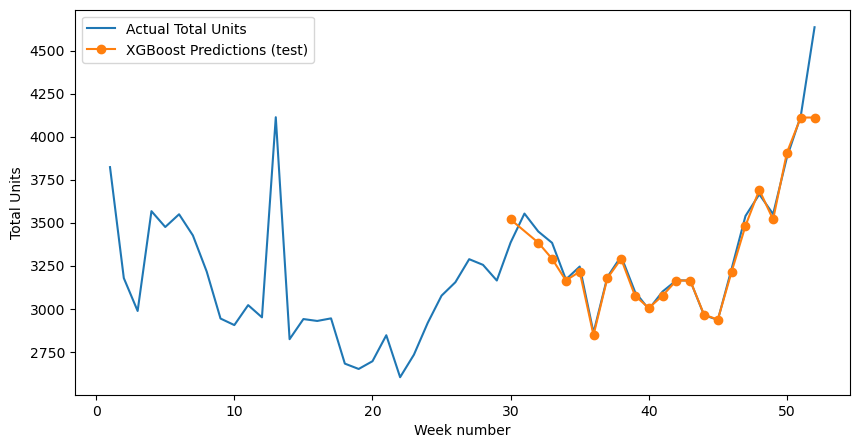

In [24]:
import matplotlib.pyplot as plt

# inverse-transform predictions and x_test to original scale
y_pred_inv = scaler_y.inverse_transform(y_pred_xgb.reshape(-1, 1)).ravel()
x_test_orig = scaler_X.inverse_transform(x_test)
week_nums_test = x_test_orig[:, 0].astype(int)

# sort by week number so the line looks correct over time
order = week_nums_test.argsort()
week_nums_test_sorted = week_nums_test[order]
y_pred_inv_sorted = y_pred_inv[order]

plt.figure(figsize=(10, 5))
plt.plot(weekly["Week number"], weekly["Total_Units"], label="Actual Total Units")
plt.plot(week_nums_test_sorted, y_pred_inv_sorted, "o-", label="XGBoost Predictions (test)")
plt.xlabel("Week number")
plt.ylabel("Total Units")
plt.legend()
plt.show()
